<a href="https://colab.research.google.com/github/muskan-dhawan/DSA-ML-GEN-AI/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading IMDB dataset...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
25000 train sequences
25000 test sequences
Pad sequences (samples x time)
input_train shape: (25000, 500)
input_test shape: (25000, 500)
Building RNN model...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compiling model...
Training model...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - acc: 0.7077 - loss: 0.5606 - val_acc: 0.8236 - val_loss: 0.4089
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - acc: 0.8347 - loss: 0.3803 - val_acc: 0.8514 - val_loss: 0.3650
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 121ms/step - acc: 0.8674 - loss: 0.3252 - val_acc: 0.7936 - val_loss: 0.4516
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 146ms/step - acc: 0.8862 - loss: 0.2886 - val_acc: 0.8608 - val_loss: 0.3384
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - acc: 0.8997 - loss: 0.2517 - val_acc: 0.7992 - val_loss: 0.4200
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 115ms/step - acc: 0.9181 - loss: 0.2174 - val_acc: 0.8268 - val_loss: 0.3907
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 126ms/step - acc: 0.9355 - loss: 0.1751 - val_acc: 0.8582 - val_loss: 0.3803
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - acc: 0.9538 - loss: 0.1317 - val_acc: 0.8136 - val_loss: 0.

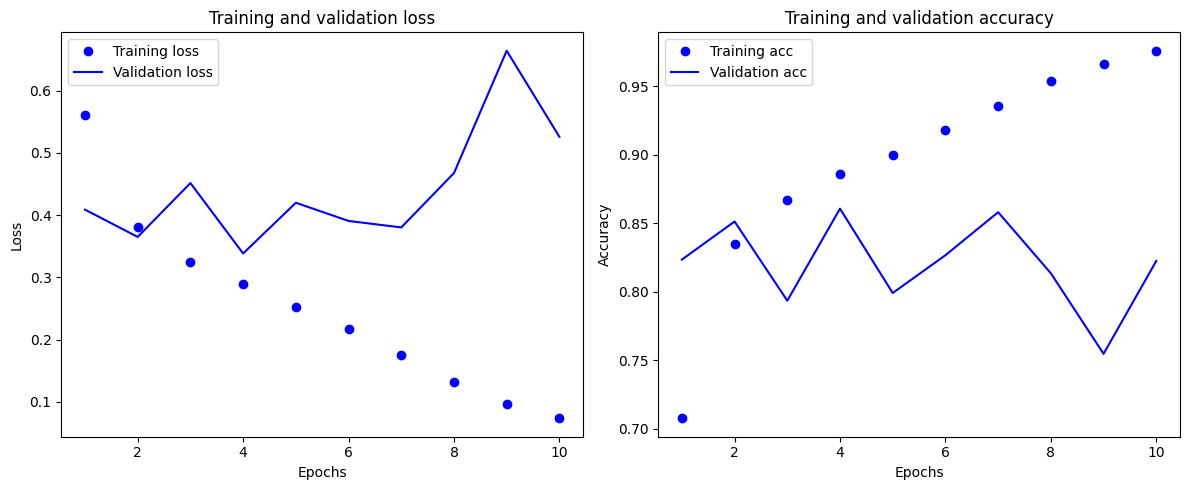

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import matplotlib.pyplot as plt

# 1. Load the IMDB dataset
print("Loading IMDB dataset...")
max_features = 10000  # Number of words to consider as features
maxlen = 500          # Cut texts after this number of words (among top max_features most common words)
batch_size = 32

(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
print(len(input_train), 'train sequences')
print(len(input_test), 'test sequences')

# 2. Preprocess the data (Padding sequences)
print('Pad sequences (samples x time)')
input_train = sequence.pad_sequences(input_train, maxlen=maxlen)
input_test = sequence.pad_sequences(input_test, maxlen=maxlen)
print('input_train shape:', input_train.shape)
print('input_test shape:', input_test.shape)

# 3. Build the RNN model
print("Building RNN model...")
model = Sequential()
model.add(Embedding(max_features, 32)) # Embedding layer for word vectors
model.add(SimpleRNN(32))               # SimpleRNN layer with 32 units
model.add(Dense(1, activation='sigmoid')) # Output layer for binary classification

model.summary()

# 4. Compile the model
print("Compiling model...")
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])

# 5. Train the model
print("Training model...")
history = model.fit(input_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)

# 6. Evaluate the model (using test data, though history already has validation metrics)
print("Evaluating model on test data...")
loss, accuracy = model.evaluate(input_test, y_test, verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

# 7. Visualize results (Training and Validation Loss and Accuracy)
print("Plotting training history...")
hist_dict = history.history
loss_values = hist_dict['loss']
val_loss_values = hist_dict['val_loss']
acc_values = hist_dict['acc']
val_acc_values = hist_dict['val_acc']
epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()